In [92]:
%pip install numpy
%pip install matplotlib
%pip install imageio


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [93]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt

In [94]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [95]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
num_rows = 10
num_cols = 15
start_state = (3, 3)
goal_state = (9, 12)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 250 # used for episodic evaluation


In [96]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
V  = np.zeros(num_states) # initialization for V(s)

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
# try looking at these functions' docs for inspiration
for i in range(max_number_iterations):
    delta = 0
    V_new = np.zeros(num_states)
    for state in range(num_states):
        if env.is_terminal_state(state):
            continue
        v_a = []
        for a in ACTIONS:
            val = 0
            for prob, next_state in env.get_transition_distribution(state, a):
                val += prob * (env.reward(state, a, next_state) + gamma * V[next_state])
            v_a.append(val)
        V_new[state] = max(v_a)
        delta = max(delta, abs(V_new[state] - V[state]))
    
    V = V_new
    if delta < threshold:
        print(f"Value Iteration converged after {i+1} iterations.")
        break

Value Iteration converged after 52 iterations.


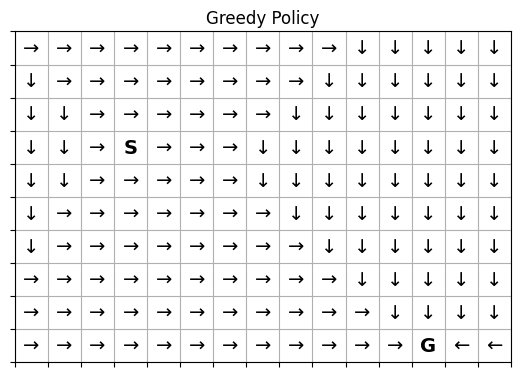

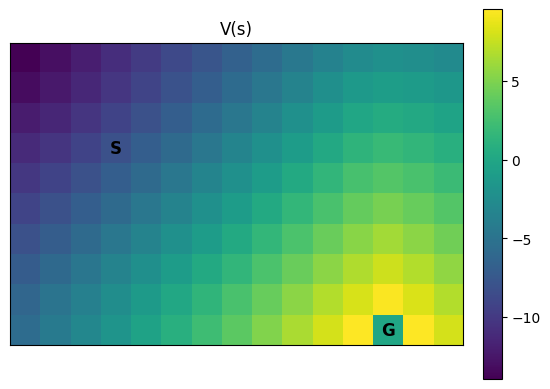

{'avg_return': -7.8, 'std_return': 2.8142, 'success_rate': 1.0, 'avg_steps': 18.8}


In [97]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

# Q-learning

In [98]:
# Q-Learning hyperparameters
n_episodes_ql = 20_000
alpha = 0.2
epsilon = 0.80
epsilon_min = 0.01
epsilon_decay = 0.9999


In [99]:
def epsilon_greedy(Q: np.ndarray, state: int, epsilon: float, rng: np.random.Generator) -> int:
    if rng.random() < epsilon:
        return int(rng.integers(len(ACTIONS)))  
    return int(np.argmax(Q[state]))


def greedy_policy_from_Q(Q: np.ndarray) -> np.ndarray:
    return np.argmax(Q, axis=1).astype(float)


def q_learning(
    env: SlipperyGridWorld,
    n_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_min: float,
    epsilon_decay: float,
    seed: int = 0,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.num_states, len(ACTIONS)))

    for _ in range(n_episodes):
        state = env.reset()
        done = False

        while not done:
            action = epsilon_greedy(Q, state, epsilon, rng)
            next_state, reward, done, _ = env.step(action)

            Q[state, action] += alpha * (reward + gamma * (0 if done else np.max(Q[next_state])) - Q[state, action])

            state = next_state

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q


In [100]:
env.reset()

Q = q_learning(
    env,
    n_episodes=n_episodes_ql,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
    seed=random_seed,
)

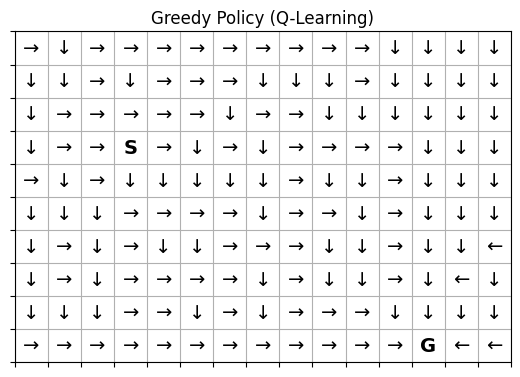

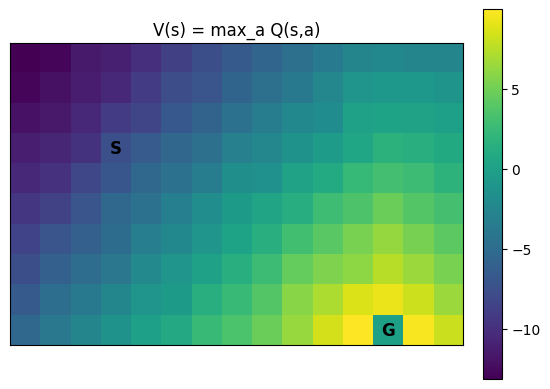

{'avg_return': -7.96, 'std_return': 3.0657, 'success_rate': 1.0, 'avg_steps': 18.96}


In [101]:
policy_plot_name_ql = "policy_QL.png"
value_plot_name_ql  = "value_QL.png"
gif_name_ql         = "episode_QL.gif"
n_val_episodes_ql   = 50

env.reset()

pi_ql = greedy_policy_from_Q(Q)

V_ql = np.max(Q, axis=1)
plot_policy(env, pi_ql, filename=policy_plot_name_ql, title="Greedy Policy (Q-Learning)")
plot_value_heatmap(env, V_ql, filename=value_plot_name_ql, title="V(s) = max_a Q(s,a)")
plt.close("all")

metrics_ql = evaluate(env, Q=Q, n_episodes=n_val_episodes_ql, seed=random_seed)
print(metrics_ql)

run_to_gif(env, Q=Q, gif_path=gif_name_ql, fps=6)


# Sarsa

In [ ]:
# sarsa parameters
n_episodes_sarsa = 20_000
alpha_sarsa = 0.2
epsilon_sarsa = 0.80
epsilon_min_sarsa = 0.01
epsilon_decay_sarsa = 0.9999


In [113]:
def sarsa(
    env: SlipperyGridWorld,
    n_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_min: float,
    epsilon_decay: float,
    seed: int = 0,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.num_states, len(ACTIONS)))

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        action = epsilon_greedy(Q, state, epsilon, rng)

        while not done:
            next_state, reward, done, _ = env.step(action)

            next_action = epsilon_greedy(Q, next_state, epsilon, rng)
            Q[state, action] += alpha * (reward + gamma * (0 if done else Q[next_state, next_action]) - Q[state, action])

            state, action = next_state, next_action

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q


In [114]:
env.reset()

Q = sarsa(
    env,
    n_episodes=n_episodes_sarsa,
    alpha=alpha_sarsa,
    gamma=gamma,
    epsilon=epsilon_sarsa,
    epsilon_min=epsilon_min_sarsa,
    epsilon_decay=epsilon_decay_sarsa,
    seed=random_seed,
)

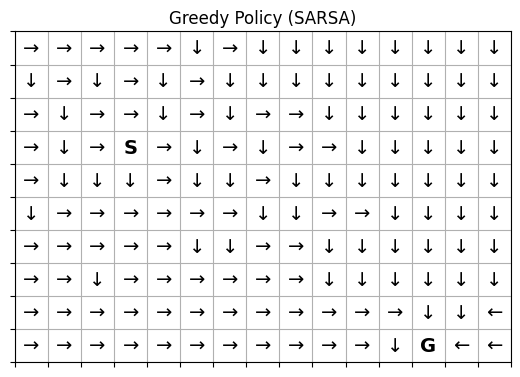

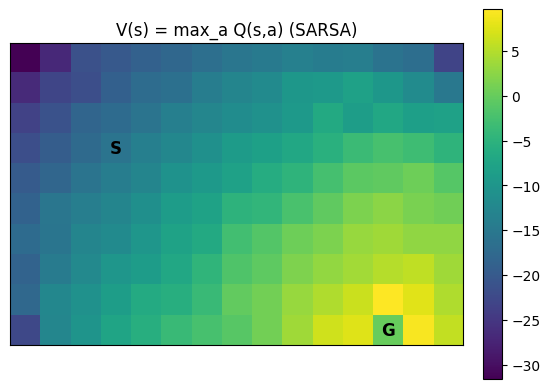

{'avg_return': -10.32, 'std_return': 6.5527, 'success_rate': 1.0, 'avg_steps': 21.32}


In [115]:
policy_plot_name_sarsa = "policy_SARSA.png"
value_plot_name_sarsa  = "value_SARSA.png"
gif_name_sarsa         = "episode_SARSA.gif"

env.reset()

pi_sarsa = greedy_policy_from_Q(Q)

V_SARSA = np.max(Q, axis=1)
plot_policy(env, pi_sarsa, filename=policy_plot_name_sarsa, title="Greedy Policy (SARSA)")
plot_value_heatmap(env, V_SARSA, filename=value_plot_name_sarsa, title="V(s) = max_a Q(s,a) (SARSA)")
plt.close("all")

metrics_sarsa = evaluate(env, Q=Q, n_episodes=n_val_episodes_ql, seed=random_seed)
print(metrics_sarsa)

run_to_gif(env, Q=Q, gif_path=gif_name_sarsa, fps=6)


# Convergence comparison

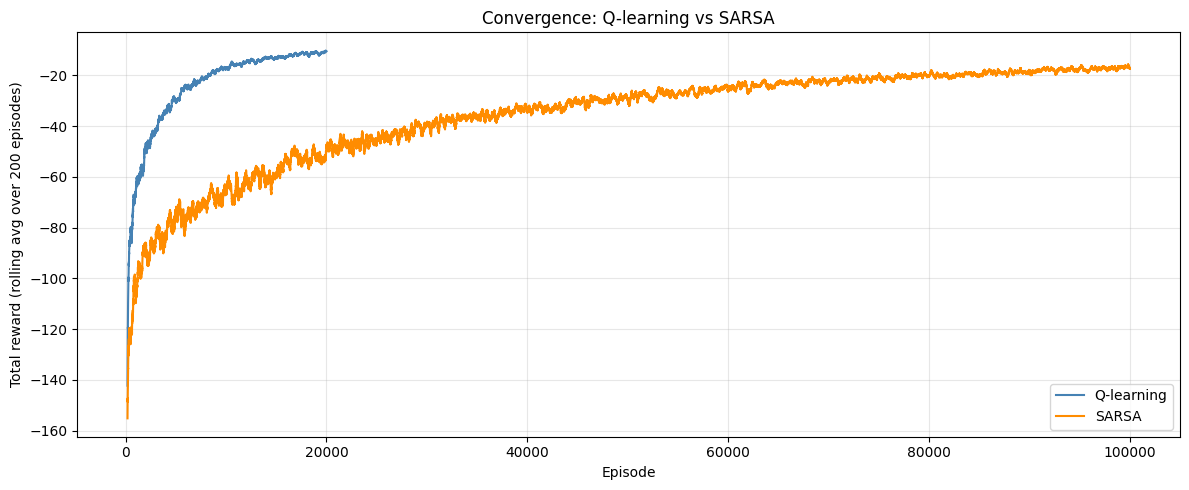

In [118]:
def q_learning_tracked(env, n_episodes, alpha, gamma, epsilon, epsilon_min, epsilon_decay, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.num_states, len(ACTIONS)))
    episode_rewards = []

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, epsilon, rng)
            next_state, reward, done, _ = env.step(action)
            Q[state, action] += alpha * (reward + gamma * (0 if done else np.max(Q[next_state])) - Q[state, action])
            state = next_state
            total_reward += reward

        episode_rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, episode_rewards


def sarsa_tracked(env, n_episodes, alpha, gamma, epsilon, epsilon_min, epsilon_decay, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.num_states, len(ACTIONS)))
    episode_rewards = []

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        action = epsilon_greedy(Q, state, epsilon, rng)
        total_reward = 0

        while not done:
            next_state, reward, done, _ = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon, rng)
            Q[state, action] += alpha * (reward + gamma * (0 if done else Q[next_state, next_action]) - Q[state, action])
            state, action = next_state, next_action
            total_reward += reward

        episode_rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, episode_rewards


_, rewards_ql = q_learning_tracked(
    env, n_episodes=n_episodes_ql, alpha=alpha, gamma=gamma,
    epsilon=epsilon, epsilon_min=epsilon_min, epsilon_decay=epsilon_decay, seed=random_seed,
)
_, rewards_sarsa = sarsa_tracked(
    env, n_episodes=n_episodes_sarsa, alpha=alpha_sarsa, gamma=gamma,
    epsilon=epsilon_sarsa, epsilon_min=epsilon_min_sarsa, epsilon_decay=epsilon_decay_sarsa, seed=random_seed,
)

# smooth with a rolling average to make the trend visible
window = 200
ql_smoothed = np.convolve(rewards_ql, np.ones(window) / window, mode="valid")
sarsa_smoothed = np.convolve(rewards_sarsa, np.ones(window) / window, mode="valid")
episodes_ql = np.arange(window - 1, window - 1 + len(ql_smoothed))
episodes_sarsa = np.arange(window - 1, window - 1 + len(sarsa_smoothed))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(episodes_ql, ql_smoothed, label="Q-learning", color="steelblue")
ax.plot(episodes_sarsa, sarsa_smoothed, label="SARSA", color="darkorange")
ax.set_xlabel("Episode")
ax.set_ylabel(f"Total reward (rolling avg over {window} episodes)")
ax.set_title("Convergence: Q-learning vs SARSA")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("convergence.png", dpi=150)
plt.show()
